#  NLP Assignment 3

## ID: i232607


In [34]:
import os
import re
import json
import random
from collections import Counter

import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [35]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
DATA_DIR = "dataset"
MODELS_DIR = "models"
RESULTS_DIR = "results"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Folders ready:", MODELS_DIR, RESULTS_DIR)

Folders ready: models results


In [36]:
# Config for dataset and preprocessing
CATEGORY_FILES = {
    "beauty": "Beauty_5.json",
    "cellphones": "Cell_Phones_and_Accessories_5.json",
    "sports": "Sports_and_Outdoors_5.json",
}

SAMPLES_PER_CATEGORY = 10000   # change to 12000 or 15000 if needed
MAX_LEN = 120                  # fixed sequence length
MIN_FREQ = 2                   # min token frequency for vocab

print("Using", SAMPLES_PER_CATEGORY, "reviews per category")

Using 10000 reviews per category


In [37]:
def read_reviews(path, category_name, limit):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                obj = json.loads(line)
            except Exception:
                continue

            text = obj.get("reviewText", "")
            rating = obj.get("overall", None)

            if text is None:
                text = ""
            text = str(text).strip()

            if rating is None:
                continue
            try:
                rating = int(round(float(rating)))
            except Exception:
                continue

            if rating < 1 or rating > 5:
                continue
            if len(text) == 0:
                continue

            rows.append({
                "text": text,
                "rating": rating,
                "category": category_name
            })

    if len(rows) < limit:
        print(f"Warning: {category_name} has only {len(rows)} usable reviews")
        return rows

    random.shuffle(rows)
    return rows[:limit]


def rating_to_sentiment(r):
    if r <= 2:
        return 0  # negative
    if r == 3:
        return 1  # neutral
    return 2      # positive


all_rows = []
for cat, file_name in CATEGORY_FILES.items():
    full_path = os.path.join(DATA_DIR, file_name)
    part = read_reviews(full_path, cat, SAMPLES_PER_CATEGORY)
    all_rows.extend(part)
    print(cat, "->", len(part))

print("Total rows:", len(all_rows))

beauty -> 10000
cellphones -> 10000
sports -> 10000
Total rows: 30000


In [38]:
# Train/val/test split: 70/15/15
train_rows, temp_rows = train_test_split(all_rows, test_size=0.30, random_state=SEED, shuffle=True)
val_rows, test_rows = train_test_split(temp_rows, test_size=0.50, random_state=SEED, shuffle=True)

print("Train:", len(train_rows))
print("Val:  ", len(val_rows))
print("Test: ", len(test_rows))


def show_label_stats(rows, name):
    sent_counts = Counter()
    cat_counts = Counter()
    for x in rows:
        sent_counts[rating_to_sentiment(x["rating"])] += 1
        cat_counts[x["category"]] += 1

    print(f"\n{name} sentiment counts (0=neg,1=neu,2=pos):", dict(sent_counts))
    print(f"{name} category counts:", dict(cat_counts))


show_label_stats(train_rows, "Train")
show_label_stats(val_rows, "Val")
show_label_stats(test_rows, "Test")

Train: 21000
Val:   4500
Test:  4500

Train sentiment counts (0=neg,1=neu,2=pos): {2: 16730, 1: 2118, 0: 2152}
Train category counts: {'sports': 7006, 'cellphones': 7002, 'beauty': 6992}

Val sentiment counts (0=neg,1=neu,2=pos): {2: 3547, 1: 473, 0: 480}
Val category counts: {'beauty': 1469, 'sports': 1498, 'cellphones': 1533}

Test sentiment counts (0=neg,1=neu,2=pos): {2: 3634, 0: 425, 1: 441}
Test category counts: {'sports': 1496, 'beauty': 1539, 'cellphones': 1465}


In [39]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\.,!?;:'\"()\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    # Split words and punctuation separately
    tokens = re.findall(r"[a-z0-9]+|[^\w\s]", text)
    return tokens


def build_vocab(rows, min_freq=2):
    counter = Counter()
    for row in rows:
        txt = clean_text(row["text"])
        tokens = tokenize(txt)
        for t in tokens:
            counter[t] += 1

    vocab = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = len(vocab)

    return vocab


def encode_tokens(tokens, vocab):
    ids = []
    unk = vocab["<UNK>"]
    for t in tokens:
        ids.append(vocab.get(t, unk))
    return ids


def pad_or_truncate(ids, max_len, pad_id=0):
    if len(ids) > max_len:
        return ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [pad_id] * (max_len - len(ids))
    return ids

In [40]:
# Build labels for second task (category prediction)
category_to_id = {
    "beauty": 0,
    "cellphones": 1,
    "sports": 2,
}
id_to_category = {v: k for k, v in category_to_id.items()}

# Build vocabulary from training data only
vocab = build_vocab(train_rows, min_freq=MIN_FREQ)
print("Vocab size:", len(vocab))


def process_rows(rows, vocab, max_len):
    x_data = []
    y_sent = []
    y_cat = []

    for row in rows:
        text = clean_text(row["text"])
        tokens = tokenize(text)
        ids = encode_tokens(tokens, vocab)
        ids = pad_or_truncate(ids, max_len=max_len, pad_id=vocab["<PAD>"])

        x_data.append(ids)
        y_sent.append(rating_to_sentiment(row["rating"]))
        y_cat.append(category_to_id[row["category"]])

    x_data = torch.tensor(x_data, dtype=torch.long)
    y_sent = torch.tensor(y_sent, dtype=torch.long)
    y_cat = torch.tensor(y_cat, dtype=torch.long)

    return x_data, y_sent, y_cat


X_train, y_train_sent, y_train_cat = process_rows(train_rows, vocab, MAX_LEN)
X_val, y_val_sent, y_val_cat = process_rows(val_rows, vocab, MAX_LEN)
X_test, y_test_sent, y_test_cat = process_rows(test_rows, vocab, MAX_LEN)

print("X_train shape:", tuple(X_train.shape))
print("X_val shape:  ", tuple(X_val.shape))
print("X_test shape: ", tuple(X_test.shape))

Vocab size: 18407
X_train shape: (21000, 120)
X_val shape:   (4500, 120)
X_test shape:  (4500, 120)


In [41]:
# Save processed data for next sections
prep_data = {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "y_train_sent": y_train_sent,
    "y_val_sent": y_val_sent,
    "y_test_sent": y_test_sent,
    "y_train_cat": y_train_cat,
    "y_val_cat": y_val_cat,
    "y_test_cat": y_test_cat,
    "vocab": vocab,
    "category_to_id": category_to_id,
    "id_to_category": id_to_category,
    "max_len": MAX_LEN,
}

torch.save(prep_data, os.path.join(RESULTS_DIR, "prep_data.pt"))
print("Saved:", os.path.join(RESULTS_DIR, "prep_data.pt"))

# Quick sanity check
print("Example token ids (first 20):", X_train[0][:20].tolist())
print("Example labels (sentiment, category):", y_train_sent[0].item(), y_train_cat[0].item())

Saved: results/prep_data.pt
Example token ids (first 20): [2, 3, 4, 5, 6, 7, 2, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Example labels (sentiment, category): 2 2


## Section 2 - Part A: Encoder-only Transformer


### Hyperparameter Tuning Log

| Run | LR   | Layers | Heads | Embed | Dropout | Val Sent Acc | Val Cat Acc |
|-----|------|--------|-------|-------|---------|--------------|-------------|
| 1   | 1e-3 | 2      | 4     | 128   | 0.1     | 0.8027 | 0.9100 |
| 2   | 5e-4 | 2      | 4     | 128   | 0.1     | 0.7882 | 0.3407 |
| 3   | 1e-3 | 3      | 4     | 128   | 0.2     | 0.8022 | 0.9056 |

In [42]:
import math
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score

In [109]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BATCH_SIZE = 64
EPOCHS = 6
LR = 1e-3
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1

Device: cuda


In [110]:
train_ds = TensorDataset(X_train, y_train_sent, y_train_cat)
val_ds = TensorDataset(X_val, y_val_sent, y_val_cat)
test_ds = TensorDataset(X_test, y_test_sent, y_test_cat)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 329
Val batches: 71
Test batches: 71


In [111]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        bsz, seq_len, _ = x.size()

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask == 0, -1e9)

        weights = torch.softmax(scores, dim=-1)
        weights = self.drop(weights)

        ctx = torch.matmul(weights, v)
        ctx = ctx.transpose(1, 2).contiguous().view(bsz, seq_len, self.d_model)

        out = self.out(ctx)
        return out

In [112]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        a = self.attn(x, attn_mask)
        x = self.norm1(x + self.drop(a))

        f = self.ff(x)
        x = self.norm2(x + self.drop(f))
        return x

In [113]:
class EncoderClassifier(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])

        self.sent_head = nn.Linear(d_model, 3)
        self.cat_head = nn.Linear(d_model, 3)

    def forward(self, x):
        bsz, seq_len = x.size()
        pos = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(bsz, seq_len)

        out = self.token_emb(x) + self.pos_emb(pos)
        out = self.drop(out)

        pad_mask = (x != 0).unsqueeze(1).unsqueeze(2)

        for layer in self.layers:
            out = layer(out, pad_mask)

        # Mean pool over non-pad tokens only
        mask = (x != 0).unsqueeze(-1).float()
        summed = (out * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        review_vec = summed / counts

        sent_logits = self.sent_head(review_vec)
        cat_logits = self.cat_head(review_vec)

        return sent_logits, cat_logits, review_vec

In [114]:
model = EncoderClassifier(
    vocab_size=len(vocab),
    max_len=MAX_LEN,
    d_model=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

criterion_sent = nn.CrossEntropyLoss()
criterion_cat = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

print(model.__class__.__name__)

EncoderClassifier


In [115]:
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_sent_true = []
    all_sent_pred = []
    all_cat_true = []
    all_cat_pred = []

    for x, y_sent, y_cat in loader:
        x = x.to(DEVICE)
        y_sent = y_sent.to(DEVICE)
        y_cat = y_cat.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            out_sent, out_cat, _ = model(x)
            loss_sent = criterion_sent(out_sent, y_sent)
            loss_cat = criterion_cat(out_cat, y_cat)
            loss = loss_sent + loss_cat

            if train_mode:
                loss.backward()
                optimizer.step()

        total_loss += loss.item()

        pred_sent = torch.argmax(out_sent, dim=1)
        pred_cat = torch.argmax(out_cat, dim=1)

        all_sent_true.extend(y_sent.cpu().numpy().tolist())
        all_sent_pred.extend(pred_sent.cpu().numpy().tolist())
        all_cat_true.extend(y_cat.cpu().numpy().tolist())
        all_cat_pred.extend(pred_cat.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader)
    sent_acc = accuracy_score(all_sent_true, all_sent_pred)
    cat_acc = accuracy_score(all_cat_true, all_cat_pred)
    sent_f1 = f1_score(all_sent_true, all_sent_pred, average="macro")
    cat_f1 = f1_score(all_cat_true, all_cat_pred, average="macro")

    return {
        "loss": avg_loss,
        "sent_acc": sent_acc,
        "cat_acc": cat_acc,
        "sent_f1": sent_f1,
        "cat_f1": cat_f1,
    }

In [116]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_sent_acc": [],
    "val_sent_acc": [],
    "train_cat_acc": [],
    "val_cat_acc": [],
}

best_val = 1e9
best_model_path = os.path.join(MODELS_DIR, "encoder.pt")

for epoch in range(1, EPOCHS + 1):
    train_stats = run_epoch(model, train_loader, optimizer=optimizer)
    val_stats = run_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_sent_acc"].append(train_stats["sent_acc"])
    history["val_sent_acc"].append(val_stats["sent_acc"])
    history["train_cat_acc"].append(train_stats["cat_acc"])
    history["val_cat_acc"].append(val_stats["cat_acc"])

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_stats['loss']:.4f} | Val Loss: {val_stats['loss']:.4f} | "
        f"Train Sent Acc: {train_stats['sent_acc']:.4f} | Val Sent Acc: {val_stats['sent_acc']:.4f} | "
        f"Train Cat Acc: {train_stats['cat_acc']:.4f} | Val Cat Acc: {val_stats['cat_acc']:.4f}"
    )

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        torch.save(model.state_dict(), best_model_path)

    scheduler.step()

print("Best model saved at:", best_model_path)

Epoch 1/6 | Train Loss: 1.2470 | Val Loss: 1.0029 | Train Sent Acc: 0.7947 | Val Sent Acc: 0.7907 | Train Cat Acc: 0.7192 | Val Cat Acc: 0.8407
Epoch 2/6 | Train Loss: 0.8897 | Val Loss: 0.9141 | Train Sent Acc: 0.8028 | Val Sent Acc: 0.7980 | Train Cat Acc: 0.8733 | Val Cat Acc: 0.8662
Epoch 3/6 | Train Loss: 0.7399 | Val Loss: 0.8525 | Train Sent Acc: 0.8125 | Val Sent Acc: 0.8078 | Train Cat Acc: 0.9155 | Val Cat Acc: 0.8947
Epoch 4/6 | Train Loss: 0.6824 | Val Loss: 0.8196 | Train Sent Acc: 0.8189 | Val Sent Acc: 0.8078 | Train Cat Acc: 0.9275 | Val Cat Acc: 0.8951
Epoch 5/6 | Train Loss: 0.6166 | Val Loss: 0.8131 | Train Sent Acc: 0.8282 | Val Sent Acc: 0.8093 | Train Cat Acc: 0.9395 | Val Cat Acc: 0.9020
Epoch 6/6 | Train Loss: 0.5930 | Val Loss: 0.8303 | Train Sent Acc: 0.8306 | Val Sent Acc: 0.8109 | Train Cat Acc: 0.9455 | Val Cat Acc: 0.9033
Best model saved at: models/encoder.pt


In [121]:
# Load best model and evaluate on test
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

test_stats = run_epoch(model, test_loader, optimizer=None)
print("\nTest Metrics")
print("Loss:", round(test_stats["loss"], 4))
print("Sentiment Accuracy:", round(test_stats["sent_acc"], 4))
print("Sentiment Macro F1:", round(test_stats["sent_f1"], 4))
print("Category Accuracy:", round(test_stats["cat_acc"], 4))
print("Category Macro F1:", round(test_stats["cat_f1"], 4))


Test Metrics
Loss: 0.7598
Sentiment Accuracy: 0.8233
Sentiment Macro F1: 0.4845
Category Accuracy: 0.9031
Category Macro F1: 0.9031


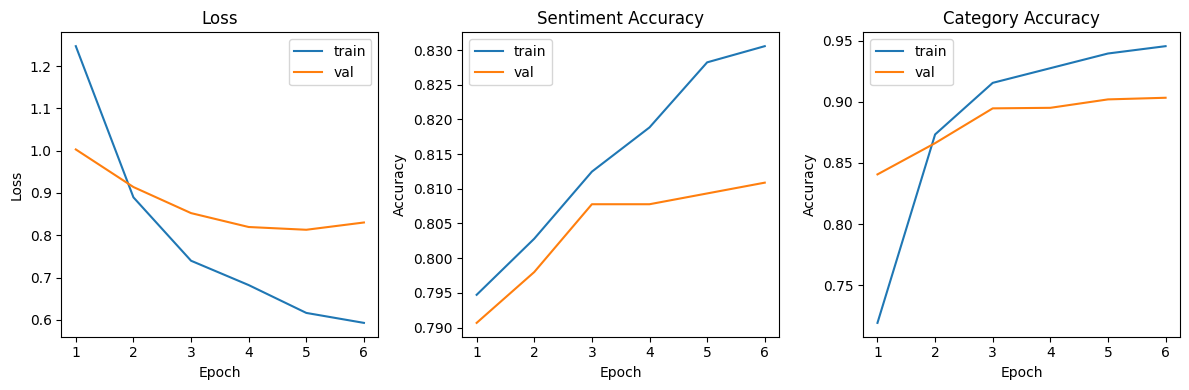

In [118]:
# Learning curves
epochs_axis = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_axis, history["train_loss"], label="train")
plt.plot(epochs_axis, history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_axis, history["train_sent_acc"], label="train")
plt.plot(epochs_axis, history["val_sent_acc"], label="val")
plt.title("Sentiment Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_axis, history["train_cat_acc"], label="train")
plt.plot(epochs_axis, history["val_cat_acc"], label="val")
plt.title("Category Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [119]:
def get_embeddings(model, x_tensor, batch_size=256):
    model.eval()
    all_vecs = []
    all_sent_pred = []
    all_cat_pred = []

    with torch.no_grad():
        for i in range(0, len(x_tensor), batch_size):
            xb = x_tensor[i:i + batch_size].to(DEVICE)
            out_sent, out_cat, vec = model(xb)

            all_vecs.append(vec.cpu())
            all_sent_pred.append(torch.argmax(out_sent, dim=1).cpu())
            all_cat_pred.append(torch.argmax(out_cat, dim=1).cpu())

    all_vecs = torch.cat(all_vecs, dim=0)
    all_sent_pred = torch.cat(all_sent_pred, dim=0)
    all_cat_pred = torch.cat(all_cat_pred, dim=0)

    return all_vecs, all_sent_pred, all_cat_pred


train_embeddings, train_sent_pred, train_cat_pred = get_embeddings(model, X_train)
val_embeddings, val_sent_pred, val_cat_pred = get_embeddings(model, X_val)
test_embeddings, test_sent_pred, test_cat_pred = get_embeddings(model, X_test)

print("Train embeddings:", tuple(train_embeddings.shape))
print("Val embeddings:", tuple(val_embeddings.shape))
print("Test embeddings:", tuple(test_embeddings.shape))

Train embeddings: (21000, 128)
Val embeddings: (4500, 128)
Test embeddings: (4500, 128)


In [120]:
# Save outputs needed for Part B
emb_path = os.path.join(RESULTS_DIR, "embeddings.pt")

torch.save({
    "train_embeddings": train_embeddings,
    "val_embeddings": val_embeddings,
    "test_embeddings": test_embeddings,
    "train_sent_pred": train_sent_pred,
    "val_sent_pred": val_sent_pred,
    "test_sent_pred": test_sent_pred,
    "train_cat_pred": train_cat_pred,
    "val_cat_pred": val_cat_pred,
    "test_cat_pred": test_cat_pred,
    "train_rows": train_rows,
    "val_rows": val_rows,
    "test_rows": test_rows,
}, emb_path)

print("Saved embeddings file:", emb_path)
print("Saved model file:", best_model_path)

Saved embeddings file: results/embeddings.pt
Saved model file: models/encoder.pt


## Section 3 - Part B: Retrieval Module

This section uses Part A review vectors to retrieve top-k most similar training reviews
using cosine similarity. Retrieved context is saved for Part C.

In [55]:
# Load saved vectors from Encoder
part_a_data = torch.load(os.path.join(RESULTS_DIR, "embeddings.pt"), map_location="cpu")

train_embeddings = part_a_data["train_embeddings"].float()
val_embeddings = part_a_data["val_embeddings"].float()
test_embeddings = part_a_data["test_embeddings"].float()

train_rows = part_a_data["train_rows"]
val_rows = part_a_data["val_rows"]
test_rows = part_a_data["test_rows"]

print("Loaded embeddings")
print("Train:", tuple(train_embeddings.shape))
print("Val:  ", tuple(val_embeddings.shape))
print("Test: ", tuple(test_embeddings.shape))

Loaded embeddings
Train: (21000, 128)
Val:   (4500, 128)
Test:  (4500, 128)


In [56]:
TOP_K = 3  # easy to change


def l2_normalize(x, eps=1e-8):
    norm = torch.norm(x, p=2, dim=1, keepdim=True)
    return x / (norm + eps)


# Pre-normalize for cosine similarity
train_emb_norm = l2_normalize(train_embeddings)
val_emb_norm = l2_normalize(val_embeddings)
test_emb_norm = l2_normalize(test_embeddings)

print("TOP_K =", TOP_K)

TOP_K = 3


In [57]:
def retrieve_top_k(query_vec, db_vectors_norm, k=3):
    # query_vec shape: (d,)
    q = query_vec.unsqueeze(0)
    q = l2_normalize(q)

    sims = torch.matmul(db_vectors_norm, q.t()).squeeze(1)
    top_vals, top_idx = torch.topk(sims, k=k)

    return top_idx.tolist(), top_vals.tolist()


def retrieve_for_split(query_vectors_norm, db_vectors_norm, db_rows, k=3):
    all_idx = []
    all_scores = []

    for i in range(query_vectors_norm.size(0)):
        idx, scores = retrieve_top_k(query_vectors_norm[i], db_vectors_norm, k=k)
        all_idx.append(idx)
        all_scores.append(scores)

    retrieved_rows = []
    for one_idx_list in all_idx:
        temp = []
        for j in one_idx_list:
            temp.append(db_rows[j])
        retrieved_rows.append(temp)

    return all_idx, all_scores, retrieved_rows

In [58]:
# Retrieve for validation and test queries against train database
val_ret_idx, val_ret_scores, val_ret_rows = retrieve_for_split(
    val_emb_norm, train_emb_norm, train_rows, k=TOP_K
)

test_ret_idx, test_ret_scores, test_ret_rows = retrieve_for_split(
    test_emb_norm, train_emb_norm, train_rows, k=TOP_K
)

print("Validation retrieval done:", len(val_ret_idx))
print("Test retrieval done:", len(test_ret_idx))
print("Each query retrieves:", TOP_K, "reviews")

Validation retrieval done: 4500
Test retrieval done: 4500
Each query retrieves: 3 reviews


In [59]:
sent_id_to_name = {0: "negative", 1: "neutral", 2: "positive"}
num_show = 3
for i in range(num_show):
    print("=" * 80)
    print("QUERY:")
    print("  Text:", test_rows[i]["text"][:200])
    print("  Sentiment:", sent_id_to_name[int(test_sent_pred[i])])
    print("  Category:", test_rows[i]["category"])
    print("RETRIEVED:")
    for j, r in enumerate(test_ret_rows[i]):
        print(f"  [{j+1}] ({r['category']}, {sent_id_to_name[rating_to_sentiment(r['rating'])]})", r["text"][:100])
    print()

QUERY:
  Text: Pros1) Reduces friction of bearing - bearing, axle nut - bearing friction2) Useful for bicycle break down - clean - reassemble on axle, bottom bracket and, fork.ConsNo problems to date.
  Sentiment: positive
  Category: sports
RETRIEVED:
  [1] (sports, positive) I watched a video on Youtube and matched how they attached it to a mossberg 500. Every thing fits ve
  [2] (sports, positive) Ordered a seat that needed a different post then came on my bike . This fit the bill and works fine 
  [3] (sports, positive) Stan's rim tape seals the rim so that you can convert to tubeless  without the expense of tubeless r

QUERY:
  Text: The product is good, it holds the nail polish in it place while you apply nail polish on ,it keep you from dropping the nail  polish wish ends up in a big mess.
  Sentiment: positive
  Category: beauty
RETRIEVED:
  [1] (beauty, positive) The other BB Cream I tried was by Hydroxatone, and was very drying.  This feels much better, but on 
  [2] (beauty,

In [60]:
def short_text(s, n=220):
    s = s.replace("\n", " ").strip()
    if len(s) <= n:
        return s
    return s[:n] + "..."


def print_retrieval_examples(query_rows, ret_rows, ret_scores, n_examples=5):
    pick = min(n_examples, len(query_rows))
    step = max(1, len(query_rows) // pick)

    shown = 0
    i = 0
    while shown < pick and i < len(query_rows):
        q = query_rows[i]
        print("=" * 90)
        print("Query", shown + 1)
        print("Query category:", q["category"], "| Query rating:", q["rating"])
        print("Query text:", short_text(q["text"]))
        print("-" * 90)

        for r in range(len(ret_rows[i])):
            item = ret_rows[i][r]
            score = ret_scores[i][r]
            print(f"Top-{r+1} | score={score:.4f} | cat={item['category']} | rating={item['rating']}")
            print(short_text(item["text"]))
            print()

        shown += 1
        i += step


print_retrieval_examples(test_rows, test_ret_rows, test_ret_scores, n_examples=5)

Query 1
Query category: sports | Query rating: 5
Query text: Pros1) Reduces friction of bearing - bearing, axle nut - bearing friction2) Useful for bicycle break down - clean - reassemble on axle, bottom bracket and, fork.ConsNo problems to date.
------------------------------------------------------------------------------------------
Top-1 | score=0.9726 | cat=sports | rating=5
I watched a video on Youtube and matched how they attached it to a mossberg 500. Every thing fits very nice and snug. For the screw that attaches the saddle to the breach I used some locktite as it will come loose. The n...

Top-2 | score=0.9675 | cat=sports | rating=5
Ordered a seat that needed a different post then came on my bike . This fit the bill and works fine . Not much to say no problems with finish or rigidness .

Top-3 | score=0.9667 | cat=sports | rating=5
Stan's rim tape seals the rim so that you can convert to tubeless  without the expense of tubeless rims.  If you ride through goat-heads, glass,

In [61]:
def retrieval_match_rate(query_rows, ret_rows):
    same_cat = 0
    same_sent = 0
    total = len(query_rows)

    for i in range(total):
        q_cat = query_rows[i]["category"]
        q_sent = rating_to_sentiment(query_rows[i]["rating"])

        hit_cat = 0
        hit_sent = 0
        for item in ret_rows[i]:
            if item["category"] == q_cat:
                hit_cat += 1
            if rating_to_sentiment(item["rating"]) == q_sent:
                hit_sent += 1

        if hit_cat > 0:
            same_cat += 1
        if hit_sent > 0:
            same_sent += 1

    return {
        "topk_has_same_category_rate": same_cat / total,
        "topk_has_same_sentiment_rate": same_sent / total,
    }


val_quality = retrieval_match_rate(val_rows, val_ret_rows)
test_quality = retrieval_match_rate(test_rows, test_ret_rows)

print("Validation retrieval quality:")
for k, v in val_quality.items():
    print(k, "=", round(v, 4))

print("\nTest retrieval quality:")
for k, v in test_quality.items():
    print(k, "=", round(v, 4))

Validation retrieval quality:
topk_has_same_category_rate = 0.9418
topk_has_same_sentiment_rate = 0.8713

Test retrieval quality:
topk_has_same_category_rate = 0.9296
topk_has_same_sentiment_rate = 0.8798


In [62]:
# Save retrieval outputs for Part C
retrieval_path = os.path.join(RESULTS_DIR, "retrieval.pt")

torch.save({
    "top_k": TOP_K,
    "val_ret_idx": val_ret_idx,
    "val_ret_scores": val_ret_scores,
    "val_ret_rows": val_ret_rows,
    "test_ret_idx": test_ret_idx,
    "test_ret_scores": test_ret_scores,
    "test_ret_rows": test_ret_rows,
    "val_quality": val_quality,
    "test_quality": test_quality,
}, retrieval_path)

print("Saved retrieval file:", retrieval_path)

Saved retrieval file: results/retrieval.pt


## Section 4 - Part C: Decoder-only Transformer for Explanation Generation

This section trains a decoder-only Transformer with causal self-attention.

Input template uses:
1. original review text
2. predicted sentiment label
3. predicted category label
4. top-k retrieved reviews

Output is a short explanation (1-2 sentences). We report perplexity and show sample generations.
We also compare retrieval vs no-retrieval (ablation).

In [63]:
# Load retrieval outputs
part_b_data = torch.load(os.path.join(RESULTS_DIR, "retrieval.pt"), map_location="cpu")

TOP_K = part_b_data["top_k"]
val_ret_rows = part_b_data["val_ret_rows"]
test_ret_rows = part_b_data["test_ret_rows"]

print("Loaded retrieval with TOP_K =", TOP_K)

Loaded retrieval with TOP_K = 3


In [64]:
# Predicted labels from Part A
train_sent_pred = part_a_data["train_sent_pred"].tolist()
val_sent_pred = part_a_data["val_sent_pred"].tolist()
test_sent_pred = part_a_data["test_sent_pred"].tolist()

train_cat_pred = part_a_data["train_cat_pred"].tolist()
val_cat_pred = part_a_data["val_cat_pred"].tolist()
test_cat_pred = part_a_data["test_cat_pred"].tolist()

sent_id_to_name = {0: "negative", 1: "neutral", 2: "positive"}
cat_id_to_name = id_to_category

In [65]:
# Build retrieval for train queries (against train database)
def build_train_retrieval(train_emb_norm, train_rows, k=3, batch_size=256):
    all_ret_rows = []
    n = train_emb_norm.size(0)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        q = train_emb_norm[start:end]  # [b, d]

        sims = torch.matmul(q, train_emb_norm.t())  # [b, n]

        # avoid retrieving itself
        for i in range(end - start):
            sims[i, start + i] = -1e9

        _, top_idx = torch.topk(sims, k=k, dim=1)

        for i in range(top_idx.size(0)):
            idx_list = top_idx[i].tolist()
            temp = []
            for j in idx_list:
                temp.append(train_rows[j])
            all_ret_rows.append(temp)

    return all_ret_rows


train_ret_rows = build_train_retrieval(train_emb_norm, train_rows, k=TOP_K, batch_size=256)
print("Train retrieval done:", len(train_ret_rows))

Train retrieval done: 21000


In [66]:
DECODER_TRAIN_LIMIT = min(12000, len(train_rows))
DECODER_VAL_LIMIT = min(2000, len(val_rows))
DECODER_TEST_LIMIT = min(2000, len(test_rows))

DECODER_MAX_LEN = 220
DECODER_MIN_FREQ = 2

print("Decoder subset sizes:", DECODER_TRAIN_LIMIT, DECODER_VAL_LIMIT, DECODER_TEST_LIMIT)

Decoder subset sizes: 12000 2000 2000


In [67]:
def make_prompt(review_text, pred_sent_id, pred_cat_id, retrieved_rows):
    pred_sent = sent_id_to_name[int(pred_sent_id)]
    pred_cat = cat_id_to_name[int(pred_cat_id)]

    parts = []
    parts.append("review: " + clean_text(review_text))
    parts.append("pred_sentiment: " + pred_sent)
    parts.append("pred_category: " + pred_cat)

    ret_text = []
    for i, r in enumerate(retrieved_rows):
        t = clean_text(r["text"])
        ret_text.append("r" + str(i + 1) + ": " + t)

    parts.append("retrieved: " + " | ".join(ret_text))
    prompt = " ; ".join(parts)
    return prompt


def make_prompt_no_retrieval(review_text, pred_sent_id, pred_cat_id):
    pred_sent = sent_id_to_name[int(pred_sent_id)]
    pred_cat = cat_id_to_name[int(pred_cat_id)]

    parts = []
    parts.append("review: " + clean_text(review_text))
    parts.append("pred_sentiment: " + pred_sent)
    parts.append("pred_category: " + pred_cat)
    prompt = " ; ".join(parts)
    return prompt


def make_target_explanation(row):
    sent = sent_id_to_name[rating_to_sentiment(row["rating"])]
    cat = row["category"]
    rating = row["rating"]
    text = clean_text(row["text"])
    words = tokenize(text)
    snippet = " ".join(words[:12])

    out = (
        "This review is " + sent + " for " + cat +
        " because the text suggests a " + sent + " opinion. " +
        "The rating is " + str(rating) + " out of 5 and key words include " + snippet + "."
    )
    return out

In [68]:
SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<BOS>", "<EOS>", "<ANS>"]


def build_decoder_vocab(samples, min_freq=2):
    counter = Counter()

    for item in samples:
        p_tokens = tokenize(clean_text(item["prompt"]))
        t_tokens = tokenize(clean_text(item["target"]))

        for t in p_tokens:
            counter[t] += 1
        for t in t_tokens:
            counter[t] += 1

    vocab = {}
    for t in SPECIAL_TOKENS:
        vocab[t] = len(vocab)

    for tok, freq in counter.items():
        if freq >= min_freq and tok not in vocab:
            vocab[tok] = len(vocab)

    return vocab


def encode_with_decoder_vocab(tokens, vocab):
    ids = []
    unk = vocab["<UNK>"]
    for t in tokens:
        ids.append(vocab.get(t, unk))
    return ids

In [69]:
def build_samples(rows, sent_pred, cat_pred, ret_rows, limit, use_retrieval=True):
    out = []
    for i in range(limit):
        row = rows[i]

        if use_retrieval:
            prompt = make_prompt(row["text"], sent_pred[i], cat_pred[i], ret_rows[i])
        else:
            prompt = make_prompt_no_retrieval(row["text"], sent_pred[i], cat_pred[i])

        target = make_target_explanation(row)
        out.append({"prompt": prompt, "target": target})

    return out


train_samples = build_samples(train_rows, train_sent_pred, train_cat_pred, train_ret_rows, DECODER_TRAIN_LIMIT, use_retrieval=True)
val_samples = build_samples(val_rows, val_sent_pred, val_cat_pred, val_ret_rows, DECODER_VAL_LIMIT, use_retrieval=True)
test_samples = build_samples(test_rows, test_sent_pred, test_cat_pred, test_ret_rows, DECODER_TEST_LIMIT, use_retrieval=True)

train_samples_no_ret = build_samples(train_rows, train_sent_pred, train_cat_pred, train_ret_rows, DECODER_TRAIN_LIMIT, use_retrieval=False)
val_samples_no_ret = build_samples(val_rows, val_sent_pred, val_cat_pred, val_ret_rows, DECODER_VAL_LIMIT, use_retrieval=False)
test_samples_no_ret = build_samples(test_rows, test_sent_pred, test_cat_pred, test_ret_rows, DECODER_TEST_LIMIT, use_retrieval=False)

print("Samples ready:", len(train_samples), len(val_samples), len(test_samples))

Samples ready: 12000 2000 2000


In [70]:
decoder_vocab = build_decoder_vocab(train_samples, min_freq=DECODER_MIN_FREQ)
print("Decoder vocab size:", len(decoder_vocab))


def encode_decoder_sample(sample, vocab, max_len):
    bos = vocab["<BOS>"]
    eos = vocab["<EOS>"]
    ans = vocab["<ANS>"]
    pad = vocab["<PAD>"]

    p_tokens = tokenize(clean_text(sample["prompt"]))
    t_tokens = tokenize(clean_text(sample["target"]))

    p_ids = encode_with_decoder_vocab(p_tokens, vocab)
    t_ids = encode_with_decoder_vocab(t_tokens, vocab)

    # sequence for causal LM
    # [BOS] prompt [ANS] target [EOS]
    ids = [bos] + p_ids + [ans] + t_ids + [eos]

    # labels: ignore prompt part, learn on target + eos
    labels = [-100] * (2 + len(p_ids)) + t_ids + [eos]

    if len(ids) > max_len:
        ids = ids[:max_len]
        labels = labels[:max_len]

    if len(ids) < max_len:
        need = max_len - len(ids)
        ids = ids + [pad] * need
        labels = labels + [-100] * need

    attn_mask = [1 if x != pad else 0 for x in ids]

    return ids, labels, attn_mask


def build_decoder_tensors(samples, vocab, max_len):
    all_ids = []
    all_labels = []
    all_mask = []

    for s in samples:
        ids, labels, m = encode_decoder_sample(s, vocab, max_len)
        all_ids.append(ids)
        all_labels.append(labels)
        all_mask.append(m)

    x = torch.tensor(all_ids, dtype=torch.long)
    y = torch.tensor(all_labels, dtype=torch.long)
    m = torch.tensor(all_mask, dtype=torch.long)
    return x, y, m


X_dec_train, Y_dec_train, M_dec_train = build_decoder_tensors(train_samples, decoder_vocab, DECODER_MAX_LEN)
X_dec_val, Y_dec_val, M_dec_val = build_decoder_tensors(val_samples, decoder_vocab, DECODER_MAX_LEN)
X_dec_test, Y_dec_test, M_dec_test = build_decoder_tensors(test_samples, decoder_vocab, DECODER_MAX_LEN)

X_dec_train_no_ret, Y_dec_train_no_ret, M_dec_train_no_ret = build_decoder_tensors(train_samples_no_ret, decoder_vocab, DECODER_MAX_LEN)
X_dec_val_no_ret, Y_dec_val_no_ret, M_dec_val_no_ret = build_decoder_tensors(val_samples_no_ret, decoder_vocab, DECODER_MAX_LEN)
X_dec_test_no_ret, Y_dec_test_no_ret, M_dec_test_no_ret = build_decoder_tensors(test_samples_no_ret, decoder_vocab, DECODER_MAX_LEN)

print("Decoder train tensor shape:", tuple(X_dec_train.shape))

Decoder vocab size: 26913
Decoder train tensor shape: (12000, 220)


In [71]:
DEC_BATCH_SIZE = 32
DEC_EPOCHS = 5
DEC_LR = 1e-3
DEC_EMBED_DIM = 128
DEC_NUM_HEADS = 4
DEC_FF_DIM = 256
DEC_NUM_LAYERS = 2
DEC_DROPOUT = 0.1

train_dec_ds = TensorDataset(X_dec_train, Y_dec_train, M_dec_train)
val_dec_ds = TensorDataset(X_dec_val, Y_dec_val, M_dec_val)
test_dec_ds = TensorDataset(X_dec_test, Y_dec_test, M_dec_test)

train_dec_loader = DataLoader(train_dec_ds, batch_size=DEC_BATCH_SIZE, shuffle=True)
val_dec_loader = DataLoader(val_dec_ds, batch_size=DEC_BATCH_SIZE, shuffle=False)
test_dec_loader = DataLoader(test_dec_ds, batch_size=DEC_BATCH_SIZE, shuffle=False)

train_dec_ds_no_ret = TensorDataset(X_dec_train_no_ret, Y_dec_train_no_ret, M_dec_train_no_ret)
val_dec_ds_no_ret = TensorDataset(X_dec_val_no_ret, Y_dec_val_no_ret, M_dec_val_no_ret)
test_dec_ds_no_ret = TensorDataset(X_dec_test_no_ret, Y_dec_test_no_ret, M_dec_test_no_ret)

train_dec_loader_no_ret = DataLoader(train_dec_ds_no_ret, batch_size=DEC_BATCH_SIZE, shuffle=True)
val_dec_loader_no_ret = DataLoader(val_dec_ds_no_ret, batch_size=DEC_BATCH_SIZE, shuffle=False)
test_dec_loader_no_ret = DataLoader(test_dec_ds_no_ret, batch_size=DEC_BATCH_SIZE, shuffle=False)

In [72]:
class DecoderSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask):
        bsz, seq_len, _ = x.size()

        q = self.q(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        causal = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).unsqueeze(0).unsqueeze(0)
        key_mask = pad_mask.unsqueeze(1).unsqueeze(2)
        full_mask = causal * key_mask

        scores = scores.masked_fill(full_mask == 0, -1e9)

        w = torch.softmax(scores, dim=-1)
        w = self.drop(w)

        ctx = torch.matmul(w, v)
        ctx = ctx.transpose(1, 2).contiguous().view(bsz, seq_len, self.d_model)
        return self.out(ctx)

In [73]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = DecoderSelfAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x, pad_mask):
        a = self.attn(x, pad_mask)
        x = self.norm1(x + self.drop(a))

        f = self.ff(x)
        x = self.norm2(x + self.drop(f))
        return x

In [74]:
class DecoderOnlyLM(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            DecoderBlock(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, pad_mask):
        bsz, seq_len = x.size()
        pos = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(bsz, seq_len)

        out = self.tok_emb(x) + self.pos_emb(pos)
        out = self.drop(out)

        for layer in self.layers:
            out = layer(out, pad_mask)

        out = self.norm(out)
        logits = self.lm_head(out)
        return logits

In [75]:
def run_decoder_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_tokens = 0

    for x, y, m in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        m = m.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(x, m)

            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = y[:, 1:].contiguous()

            loss = nn.functional.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                ignore_index=-100,
                reduction="sum"
            )

            valid = (shift_labels != -100).sum().item()

            if train_mode:
                (loss / max(valid, 1)).backward()
                optimizer.step()

        total_loss += loss.item()
        total_tokens += valid

    avg_nll = total_loss / max(total_tokens, 1)
    ppl = math.exp(avg_nll)
    return avg_nll, ppl


def train_decoder_system(train_loader_use, val_loader_use, save_name):
    model = DecoderOnlyLM(
        vocab_size=len(decoder_vocab),
        max_len=DECODER_MAX_LEN,
        d_model=DEC_EMBED_DIM,
        num_heads=DEC_NUM_HEADS,
        ff_dim=DEC_FF_DIM,
        num_layers=DEC_NUM_LAYERS,
        dropout=DEC_DROPOUT,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=DEC_LR)

    hist = {"train_ppl": [], "val_ppl": []}
    best_val = 1e9
    save_path = os.path.join(MODELS_DIR, save_name)

    for epoch in range(1, DEC_EPOCHS + 1):
        train_nll, train_ppl = run_decoder_epoch(model, train_loader_use, optimizer=optimizer)
        val_nll, val_ppl = run_decoder_epoch(model, val_loader_use, optimizer=None)

        hist["train_ppl"].append(train_ppl)
        hist["val_ppl"].append(val_ppl)

        print(
            f"Epoch {epoch}/{DEC_EPOCHS} | "
            f"Train PPL: {train_ppl:.4f} | Val PPL: {val_ppl:.4f}"
        )

        if val_nll < best_val:
            best_val = val_nll
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    return model, hist, save_path

In [76]:
# Train full system (with retrieval)
decoder_model, decoder_hist, decoder_path = train_decoder_system(
    train_dec_loader,
    val_dec_loader,
    save_name="decoder_with_retrieval.pt"
)

# Test perplexity
test_nll, test_ppl = run_decoder_epoch(decoder_model, test_dec_loader, optimizer=None)
print("\nTest perplexity (with retrieval):", round(test_ppl, 4))
print("Saved:", decoder_path)

Epoch 1/5 | Train PPL: 11.0820 | Val PPL: 5.6634
Epoch 2/5 | Train PPL: 4.8942 | Val PPL: 4.9485
Epoch 3/5 | Train PPL: 4.0864 | Val PPL: 4.5271
Epoch 4/5 | Train PPL: 3.4976 | Val PPL: 4.2000
Epoch 5/5 | Train PPL: 2.8742 | Val PPL: 3.1022

Test perplexity (with retrieval): 3.0896
Saved: models/decoder_with_retrieval.pt


In [77]:
def short_text(text, max_chars):
    if len(text) <= max_chars:
        return text
    return text[:max_chars] + "..."

In [78]:
# Train baseline (without retrieval)
decoder_model_no_ret, decoder_hist_no_ret, decoder_path_no_ret = train_decoder_system(
    train_dec_loader_no_ret,
    val_dec_loader_no_ret,
    save_name="decoder_without_retrieval.pt"
)

test_nll_no_ret, test_ppl_no_ret = run_decoder_epoch(decoder_model_no_ret, test_dec_loader_no_ret, optimizer=None)
print("\nTest perplexity (without retrieval):", round(test_ppl_no_ret, 4))
print("Saved:", decoder_path_no_ret)

Epoch 1/5 | Train PPL: 11.8158 | Val PPL: 5.9268
Epoch 2/5 | Train PPL: 5.1534 | Val PPL: 4.7555
Epoch 3/5 | Train PPL: 3.7489 | Val PPL: 2.6459
Epoch 4/5 | Train PPL: 2.2315 | Val PPL: 1.7904
Epoch 5/5 | Train PPL: 1.6430 | Val PPL: 1.5163

Test perplexity (without retrieval): 1.4952
Saved: models/decoder_without_retrieval.pt


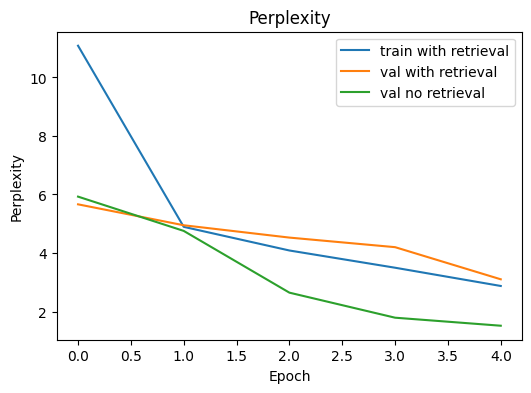

In [79]:
def decode_ids(ids, vocab):
    id_to_tok = {v: k for k, v in vocab.items()}
    toks = []
    for x in ids:
        tok = id_to_tok.get(int(x), "<UNK>")
        if tok in ["<PAD>", "<BOS>"]:
            continue
        if tok == "<EOS>":
            break
        toks.append(tok)

    text = " ".join(toks)
    text = re.sub(r"\s+([\.,!?;:])", r"\1", text)
    return text


def build_generation_input(prompt, vocab, max_len):
    bos = vocab["<BOS>"]
    ans = vocab["<ANS>"]
    ids = [bos] + encode_with_decoder_vocab(tokenize(clean_text(prompt)), vocab) + [ans]

    if len(ids) > max_len:
        ids = ids[:max_len]
    return ids


def generate_explanation(model, prompt, vocab, max_len, max_new_tokens=50):
    model.eval()
    eos_id = vocab["<EOS>"]
    pad_id = vocab["<PAD>"]

    ids = build_generation_input(prompt, vocab, max_len)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            x = ids[:max_len]
            m = [1] * len(x)

            if len(x) < max_len:
                need = max_len - len(x)
                x = x + [pad_id] * need
                m = m + [0] * need

            x_t = torch.tensor([x], dtype=torch.long, device=DEVICE)
            m_t = torch.tensor([m], dtype=torch.long, device=DEVICE)

            logits = model(x_t, m_t)
            pos = min(len(ids), max_len) - 1
            next_id = int(torch.argmax(logits[0, pos]).item())
            ids.append(next_id)

            if next_id == eos_id or len(ids) >= max_len:
                break

    return decode_ids(ids, vocab)


plt.figure(figsize=(6, 4))
plt.plot(decoder_hist["train_ppl"], label="train with retrieval")
plt.plot(decoder_hist["val_ppl"], label="val with retrieval")
plt.plot(decoder_hist_no_ret["val_ppl"], label="val no retrieval")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity")
plt.legend()
plt.show()

In [80]:
print("Ablation summary")
print("With retrieval PPL:   ", round(test_ppl, 4))
print("Without retrieval PPL:", round(test_ppl_no_ret, 4))

if test_ppl < test_ppl_no_ret:
    print("Retrieval improved perplexity.")
else:
    print("No-retrieval performed better on perplexity in this run.")

print("\nGenerated examples (at least 5)")

num_examples = 5
step = max(1, len(test_samples) // num_examples)
shown = 0
i = 0

while shown < num_examples and i < len(test_samples):
    prompt = test_samples[i]["prompt"]
    gen = generate_explanation(decoder_model, prompt, decoder_vocab, DECODER_MAX_LEN, max_new_tokens=50)

    print("=" * 100)
    print("Example", shown + 1)
    print("Prompt:", short_text(prompt, 260))
    print("Generated:", gen)

    shown += 1
    i += step

Ablation summary
With retrieval PPL:    3.0896
Without retrieval PPL: 1.4952
No-retrieval performed better on perplexity in this run.

Generated examples (at least 5)
Example 1
Prompt: review: pros1) reduces friction of bearing - bearing, axle nut - bearing friction2) useful for bicycle break down - clean - reassemble on axle, bottom bracket and, fork.consno problems to date. ; pred_sentiment: positive ; pred_category: sports ; retrieved: r1...
Generated: review: pros1 ) reduces friction of bearing - bearing, axle nut - bearing <UNK> ) useful for bicycle break down - clean - reassemble on axle, bottom bracket and, fork. <UNK> problems to date.; pred sentiment: positive; pred category: sports; retrieved: r1: i watched a video on youtube and matched how they attached it to a mossberg 500. every thing fits very nice and snug. for the screw that attaches the saddle to the breach i used some locktite as it will come loose. the nut does not have many threads to work with when attaching it. i

In [84]:
# Save explanation outputs
output_path = os.path.join(RESULTS_DIR, "explanation_outputs.pt")

torch.save({
    "with_retrieval_test_ppl": float(test_ppl),
    "without_retrieval_test_ppl": float(test_ppl_no_ret),
    "decoder_vocab": decoder_vocab,
    "decoder_max_len": DECODER_MAX_LEN,
    "top_k": TOP_K,
    "train_limit": DECODER_TRAIN_LIMIT,
    "val_limit": DECODER_VAL_LIMIT,
    "test_limit": DECODER_TEST_LIMIT,
}, output_path)

print("output path:", output_path)

output path: results/explanation_outputs.pt


In [82]:
def retrieval_match_rate(query_rows, ret_rows):
    same_cat = 0
    same_sent = 0
    total = len(query_rows)

    for i in range(total):
        q_cat = query_rows[i]["category"]
        q_sent = rating_to_sentiment(query_rows[i]["rating"])

        hit_cat = 0
        hit_sent = 0
        for item in ret_rows[i]:
            if item["category"] == q_cat:
                hit_cat += 1
            if rating_to_sentiment(item["rating"]) == q_sent:
                hit_sent += 1

        if hit_cat > 0:
            same_cat += 1
        if hit_sent > 0:
            same_sent += 1

    return {
        "topk_has_same_category_rate": same_cat / total,
        "topk_has_same_sentiment_rate": same_sent / total,
    }


val_quality = retrieval_match_rate(val_rows, val_ret_rows)
test_quality = retrieval_match_rate(test_rows, test_ret_rows)

print("Validation retrieval quality:")
for k, v in val_quality.items():
    print(k, "=", round(v, 4))

print("\nTest retrieval quality:")
for k, v in test_quality.items():
    print(k, "=", round(v, 4))

Validation retrieval quality:
topk_has_same_category_rate = 0.9418
topk_has_same_sentiment_rate = 0.8713

Test retrieval quality:
topk_has_same_category_rate = 0.9296
topk_has_same_sentiment_rate = 0.8798


In [83]:
# Save retrieval outputs for Part C
retrieval_path = os.path.join(RESULTS_DIR, "retrieval.pt")

torch.save({
    "top_k": TOP_K,
    "val_ret_idx": val_ret_idx,
    "val_ret_scores": val_ret_scores,
    "val_ret_rows": val_ret_rows,
    "test_ret_idx": test_ret_idx,
    "test_ret_scores": test_ret_scores,
    "test_ret_rows": test_ret_rows,
    "val_quality": val_quality,
    "test_quality": test_quality,
}, retrieval_path)

print("Saved retrieval file:", retrieval_path)

Saved retrieval file: results/retrieval.pt
